# Part 1: Credit Risk Default Prediction

Dataset: Kaggle "Give Me Some Credit"

**Load data, explore missingness and class imbalance**

In [40]:
import pandas as pd
import numpy as np

data_dir = r'C:\Users\User\Downloads\credit-risk-project\data'

train = pd.read_csv(data_dir + r'\cs-training.csv', index_col=0)
test = pd.read_csv(data_dir + r'\cs-test.csv', index_col=0)
solutions_for_test = pd.read_csv(data_dir + r'\sampleEntry.csv', index_col=0)

print(train.shape, test.shape)
train.head()

(150000, 11) (101503, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [41]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [42]:
train.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [43]:
train['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [44]:
train['NumberOfDependents'].value_counts(normalize=True).sort_index()

NumberOfDependents
0.0     0.594909
1.0     0.180153
2.0     0.133643
3.0     0.064918
4.0     0.019593
5.0     0.005107
6.0     0.001082
7.0     0.000349
8.0     0.000164
9.0     0.000034
10.0    0.000034
13.0    0.000007
20.0    0.000007
Name: proportion, dtype: float64

In [45]:
from sklearn.model_selection import train_test_split

X = train.drop(columns='SeriousDlqin2yrs')
y = train['SeriousDlqin2yrs']

X_train, X_val, y_train, y_val = train_test_split(                              # split data into training (80%) and validation set (20%)
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_val.shape)
print(y_train.mean(), y_val.mean())

(120000, 10) (30000, 10)
0.06684166666666666 0.06683333333333333


**Cell below removes outliers in RevolvingUtilizationOfUnsecuredLines column because we can see from train.describe() that max is unreasonably high**

In [46]:
cap = X_train['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)   # top 1% removed
print('cap value:', cap)

X_train_capped = X_train.copy()
X_val_capped = X_val.copy()
X_train_capped['RevolvingUtilizationOfUnsecuredLines'] = X_train_capped['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap)    # replaces values above cap with cap
X_val_capped['RevolvingUtilizationOfUnsecuredLines'] = X_val_capped['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap)

cap value: 1.0944386634299974


**Cell below shows the total rows corresponding to debt ratio > 1 and > 10. This suspicion came about due to unreasonably high debt ratio as seen in max**

In [47]:
print('rows with DebtRatio > 1:', (X_train['DebtRatio'] > 1).sum())
print('rows with DebtRatio > 10:', (X_train['DebtRatio'] > 10).sum())

rows with DebtRatio > 1: 27987
rows with DebtRatio > 10: 23019


**Hypothesis: outlier debt ratios came about due to missing MonthlyIncome values. Cell below supports the hypothesis because the mean for > 10 is close to 1 and <= 10 close to 0**

In [48]:
high_debt_ratio = X_train['DebtRatio'] > 10

print('MonthlyIncome missing rate when DebtRatio > 10:', X_train.loc[high_debt_ratio, 'MonthlyIncome'].isnull().mean())
print('MonthlyIncome missing rate when DebtRatio <= 10:', X_train.loc[~high_debt_ratio, 'MonthlyIncome'].isnull().mean())

MonthlyIncome missing rate when DebtRatio > 10: 0.9255397714931144
MonthlyIncome missing rate when DebtRatio <= 10: 0.02443777647168002


**Cell below converts the likely misinformed debt ratios (total payments inputed instead of ratios) corresponding to missing MonthlyIncome row to ratio by dividing by median of training set**

In [49]:
X_train_v2 = X_train_capped.copy()
X_val_v2 = X_val_capped.copy()

X_train_v2['MonthlyIncome_was_missing'] = X_train['MonthlyIncome'].isnull().astype(int)
X_val_v2['MonthlyIncome_was_missing'] = X_val['MonthlyIncome'].isnull().astype(int)

X_train_v2.loc[X_train_v2['MonthlyIncome_was_missing'] == 1, 'DebtRatio'] = X_train_v2.loc[X_train_v2['MonthlyIncome_was_missing'] == 1, 'DebtRatio'] / X_train_v2['MonthlyIncome'].median()
X_val_v2.loc[X_val_v2['MonthlyIncome_was_missing'] == 1, 'DebtRatio'] = X_val_v2.loc[X_val_v2['MonthlyIncome_was_missing'] == 1, 'DebtRatio'] / X_train_v2['MonthlyIncome'].median()

X_train_v2 = X_train_v2.drop(columns='MonthlyIncome_was_missing')
X_val_v2 = X_val_v2.drop(columns='MonthlyIncome_was_missing')


In [50]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')            # only 1 strategy for each columns with missing values

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_v2), columns=X_train_v2.columns, index=X_train_v2.index        # fit_transform(X_train) = fit(X_train) + transform(X_train), 'fit' learns the statistic (median for each column in this case)
                                                                                        # and stores it in imputer, then immediately applies to missing columns 
)
X_val_imputed = pd.DataFrame(
    imputer.transform(X_val_v2), columns=X_val_v2.columns, index=X_val_v2.index                  # uses the same stored median in fit(X_train) and apply to X_val instead 
)

X_train_imputed.isnull().sum().sum(), X_val_imputed.isnull().sum().sum()


(0, 0)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns, index=X_train_imputed.index      # scalar.fit_transform learns the mean and std of each column and stores it in scaler object, then transforms each column by (x-mean)/std
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imputed), columns=X_val_imputed.columns, index=X_val_imputed.index    # uses the stored mean and std to transform each column of x_val by (x-mean)/std
)

X_train_scaled.describe().loc[['mean', 'std']]


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
mean,8.230453e-17,9.764041e-17,1.243450e-18,-1.065814e-17,2.250052e-18,7.117270e-17,-1.018445e-17,-1.030287e-17,2.735590e-17,2.498742e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model = LogisticRegression(random_state=42)      # argument not needed for this model but when using other models with randomness built into it (new output everytime we run) we include this seed to fix the output
model.fit(X_train_scaled, y_train)           # fit a logistic regression curve to data

val_proba = model.predict_proba(X_val_scaled)[:, 1]      # get probabilities of default for each person
roc_auc_score(y_val, val_proba)           # tells us how well the model ranks defaulter above non-defaulters


0.812051849301554

In [53]:
from sklearn.metrics import classification_report

val_pred = model.predict(X_val_scaled)       # tells who defaulted and who didnt based on threshold = 0.5
print(classification_report(y_val, val_pred))


              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.61      0.05      0.10      2005

    accuracy                           0.93     30000
   macro avg       0.78      0.53      0.53     30000
weighted avg       0.91      0.93      0.91     30000



In [54]:
threshold = 0.2
val_pred_thresh = (val_proba >= threshold).astype(int)    # val_proba >= threshold returns an array of true/false and .astype(int) converts to 0/1
print(classification_report(y_val, val_pred_thresh))


              precision    recall  f1-score   support

           0       0.95      0.94      0.95     27995
           1       0.31      0.38      0.34      2005

    accuracy                           0.90     30000
   macro avg       0.63      0.66      0.64     30000
weighted avg       0.91      0.90      0.91     30000



**Cell below shows optimum (precision, recall) pair that maximizes unweighted F1 score, we know this is inaccurate because precision and recall can't be treated equally as recall
matters more than precision (we need the model to flag more defaulters because it's more risky)**

In [55]:
from sklearn.metrics import precision_recall_curve

lr_precisions, lr_recalls, lr_thresholds = precision_recall_curve(y_val, val_proba)
lr_f1_scores = 2 * lr_precisions * lr_recalls / (lr_precisions + lr_recalls + 1e-12)         # small adjustment to handle (0,0), since we know limit goes to 0 as it approaches (0,0)
lr_f1_scores = lr_f1_scores[:-1]                                                            # last precision/recall point has no corresponding threshold
lr_best_idx = np.argmax(lr_f1_scores)
lr_best_threshold = lr_thresholds[lr_best_idx]

print(f'best threshold: {lr_best_threshold:.4f}')
print(f'precision: {lr_precisions[lr_best_idx]:.4f}, recall: {lr_recalls[lr_best_idx]:.4f}, f1: {lr_f1_scores[lr_best_idx]:.4f}')

best threshold: 0.2047
precision: 0.3241, recall: 0.3681, f1: 0.3447


**We used another model (XGBOOST) to predict P.O.D , comparisons were made between the 2 models**

In [56]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_imputed, y_train)

xgb_val_proba = xgb_model.predict_proba(X_val_imputed)[:, 1]
roc_auc_score(y_val, xgb_val_proba)


0.8588864060602202

**Cell below shows that AUC of XGBOOST > AUC L.R indicating that XGBOOST is the better model**

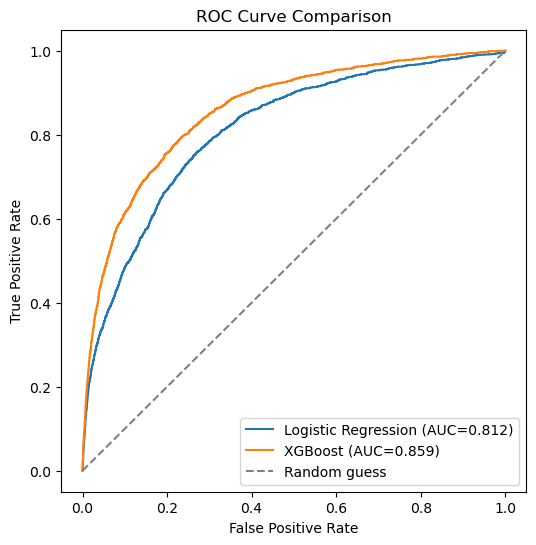

In [57]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_val, val_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_val_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_val, val_proba):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_val, xgb_val_proba):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


In [58]:
xgb_val_pred = xgb_model.predict(X_val_imputed)
print(classification_report(y_val, xgb_val_pred))


              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.57      0.21      0.31      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.60      0.64     30000
weighted avg       0.92      0.94      0.92     30000



In [59]:

xgb_val_pred_thresh = (xgb_val_proba >= threshold).astype(int)    # xgb_val_proba >= threshold returns an array of true/false and .astype(int) converts to 0/1
print(classification_report(y_val, xgb_val_pred_thresh))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27995
           1       0.38      0.50      0.43      2005

    accuracy                           0.91     30000
   macro avg       0.67      0.72      0.69     30000
weighted avg       0.92      0.91      0.92     30000



In [60]:
precisions, recalls, thresholds = precision_recall_curve(y_val, xgb_val_proba)

f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)    
f1_scores = f1_scores[:-1]  

best_idx = np.argmax(f1_scores)   
best_threshold = thresholds[best_idx]

print(f'best threshold: {best_threshold:.4f}')
print(f'precision: {precisions[best_idx]:.4f}, recall: {recalls[best_idx]:.4f}, f1: {f1_scores[best_idx]:.4f}')



best threshold: 0.2338
precision: 0.4130, recall: 0.4628, f1: 0.4365


**From the graphs below, we can see that at similar maximum threshold, XGBOOST was able to predict more defaulters (higher recall) and was also more 'precise' (i.e less false positives out of all predicted defaulters)**

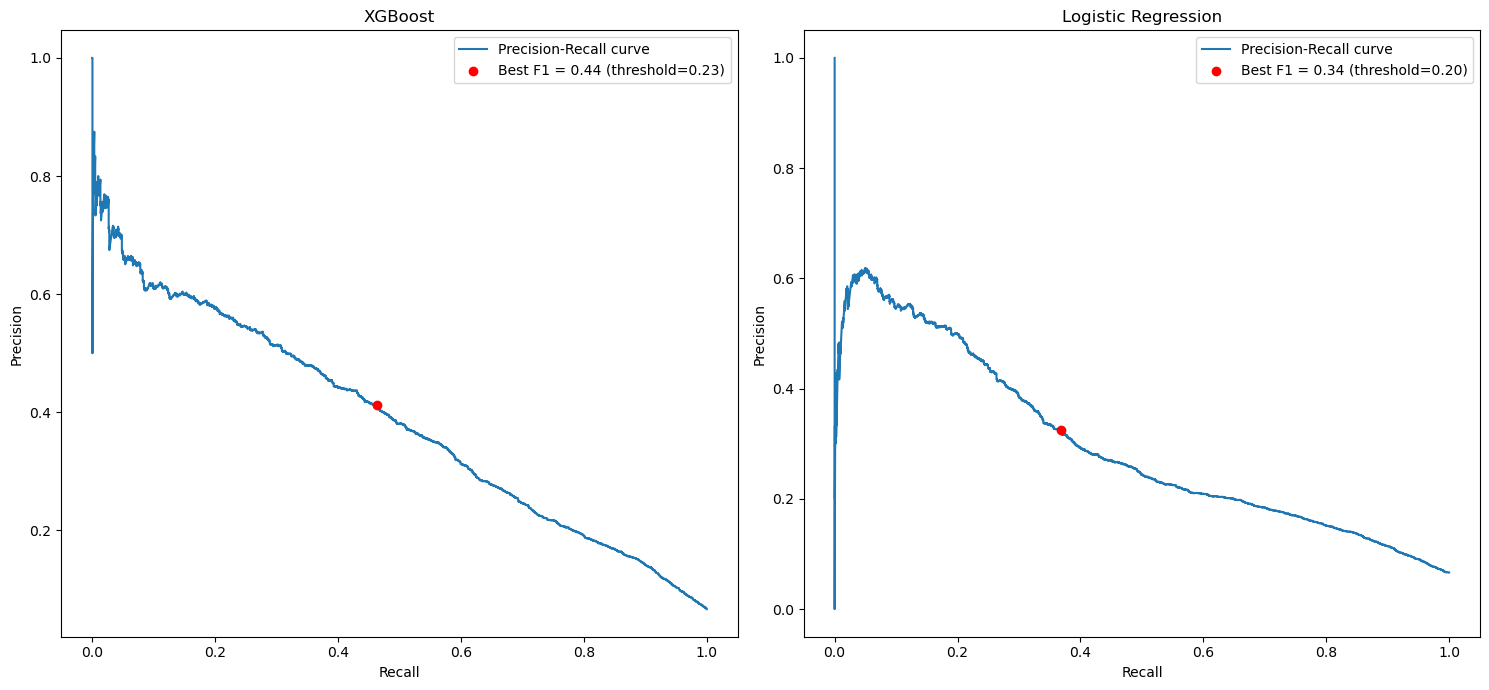

In [61]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].plot(recalls, precisions, label='Precision-Recall curve')
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5,
                label=f'Best F1 = {f1_scores[best_idx]:.2f} (threshold={best_threshold:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('XGBoost')
axes[0].legend()

axes[1].plot(lr_recalls, lr_precisions, label='Precision-Recall curve')
axes[1].scatter(lr_recalls[lr_best_idx], lr_precisions[lr_best_idx], color='red', zorder=5,
                label=f'Best F1 = {lr_f1_scores[lr_best_idx]:.2f} (threshold={lr_best_threshold:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()


**Cell below shows the significance of each variable in XGBOOST, all percentages make logical sense, no negative values as we will see with Logistic Regression.**

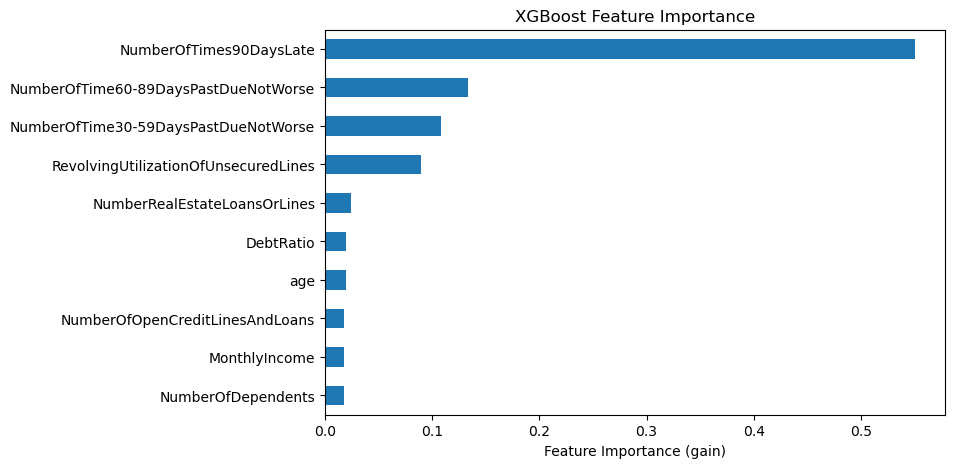

NumberOfTimes90DaysLate                 0.550664
NumberOfTime60-89DaysPastDueNotWorse    0.133831
NumberOfTime30-59DaysPastDueNotWorse    0.108486
RevolvingUtilizationOfUnsecuredLines    0.089844
NumberRealEstateLoansOrLines            0.024841
DebtRatio                               0.019933
age                                     0.019314
NumberOfOpenCreditLinesAndLoans         0.017832
MonthlyIncome                           0.017690
NumberOfDependents                      0.017565
dtype: float32

In [62]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train_imputed.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance (gain)')
plt.title('XGBoost Feature Importance')
plt.show()

importances


**Cell below shows the significance of each variable in Logistic Regression, i.e the beta values. All betas make sense except a problem with NumberOfTime60-89DaysPastDueNotWorse being negative as opposed to positive. We should expect when NumberOfTime60-89DaysPastDueNotWorse increases, P.O.D increases but this shows the opposite.**

In [63]:
pd.Series(model.coef_[0], index=X_train_scaled.columns).sort_values(key=abs, ascending=False)

NumberOfTime60-89DaysPastDueNotWorse   -2.350912
NumberOfTime30-59DaysPastDueNotWorse    1.253257
NumberOfTimes90DaysLate                 1.205193
RevolvingUtilizationOfUnsecuredLines    0.901474
MonthlyIncome                          -0.342558
age                                    -0.221340
NumberOfOpenCreditLinesAndLoans         0.151725
NumberRealEstateLoansOrLines            0.082274
NumberOfDependents                      0.076254
DebtRatio                              -0.035231
dtype: float64

**Cell below shows the 3 columns are almost perfectly correlated**

In [64]:
late_payment_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']
X_train[late_payment_cols].corr()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
NumberOfTime30-59DaysPastDueNotWorse,1.000000,0.986941,0.983642
NumberOfTime60-89DaysPastDueNotWorse,0.986941,1.000000,0.992823
NumberOfTimes90DaysLate,0.983642,0.992823,1.000000


**We further investigate the root of correlation and observed that there are exactly 212 rows with 98 and 2 rows with 96 for each column.**

In [65]:
print(X_train[late_payment_cols].describe())
print()
for col in late_payment_cols:
    print(col)
    print(X_train[col].value_counts().sort_index(ascending=False).head(5))
    print()


       NumberOfTime30-59DaysPastDueNotWorse  \
count                         120000.000000   
mean                               0.420075   
std                                4.182138   
min                                0.000000   
25%                                0.000000   
50%                                0.000000   
75%                                0.000000   
max                               98.000000   

       NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate  
count                         120000.000000            120000.000000  
mean                               0.239858                 0.264942  
std                                4.144569                 4.158242  
min                                0.000000                 0.000000  
25%                                0.000000                 0.000000  
50%                                0.000000                 0.000000  
75%                                0.000000                 0.000000  
max     

**Cell below further shows that all the 96 and 98 values for each column lie in the same row as seen from the 214 True values (212 + 2), most likely being inputed as duplicates**

In [66]:
(X_train_v2[late_payment_cols] >= 96).all(axis=1).value_counts()        # if all of the three columns has a True value, it returns True, otherwise false  

False    119786
True        214
Name: count, dtype: int64

**We then convert the correlated rows to missing values so that we can use the imputer to fill the missing values with the median. Here the median is good choice because the columns contain mostly 0. We obtained an AUC = 0.854 which is a significant improvement from before of 0.812 and now comparable to xgboost (0.859) as will see below.**

In [67]:
X_train_v3 = X_train_v2.copy()
X_val_v3 = X_val_v2.copy()

sentinel_mask_train = (X_train[late_payment_cols] >= 96).all(axis=1)       
sentinel_mask_val = (X_val[late_payment_cols] >= 96).all(axis=1)

X_train_v3['HasSentinelLatePaymentValue'] = sentinel_mask_train.astype(int)
X_val_v3['HasSentinelLatePaymentValue'] = sentinel_mask_val.astype(int)

X_train_v3.loc[sentinel_mask_train, late_payment_cols] = np.nan      # change the rows of the three columns correponding to True to NaN, can be done because all the 96 and 98 values all lie on the same row, e.g 96-96-96, 98-98-98. Otherwise, cant be done because we are throwing away real data
X_val_v3.loc[sentinel_mask_val, late_payment_cols] = np.nan

X_train_v3 = X_train_v3.drop(columns=['HasSentinelLatePaymentValue'])
X_val_v3 = X_val_v3.drop(columns=['HasSentinelLatePaymentValue'])

imputer_v3 = SimpleImputer(strategy='median')
X_train_v3_imputed = pd.DataFrame(
    imputer_v3.fit_transform(X_train_v3), columns=X_train_v3.columns, index=X_train_v3.index
)
X_val_v3_imputed = pd.DataFrame(
    imputer_v3.transform(X_val_v3), columns=X_val_v3.columns, index=X_val_v3.index
)

scaler_v3 = StandardScaler()
X_train_v3_scaled = pd.DataFrame(
    scaler_v3.fit_transform(X_train_v3_imputed), columns=X_train_v3_imputed.columns, index=X_train_v3_imputed.index
)
X_val_v3_scaled = pd.DataFrame(
    scaler_v3.transform(X_val_v3_imputed), columns=X_val_v3_imputed.columns, index=X_val_v3_imputed.index
)

model_v3 = LogisticRegression(random_state=42)
model_v3.fit(X_train_v3_scaled, y_train)

val_proba_v3 = model_v3.predict_proba(X_val_v3_scaled)[:, 1]
roc_auc_score(y_val, val_proba_v3)

0.8542283868824101

**Beta values now make more sense as NumberOfTimes90DaysLate is positive**

In [68]:
pd.Series(model_v3.coef_[0], index=X_train_v3_scaled.columns).sort_values(key=abs, ascending=False)


RevolvingUtilizationOfUnsecuredLines    0.731122
NumberOfTimes90DaysLate                 0.313724
NumberOfTime30-59DaysPastDueNotWorse    0.289266
MonthlyIncome                          -0.280896
age                                    -0.255584
NumberOfTime60-89DaysPastDueNotWorse    0.203316
NumberOfOpenCreditLinesAndLoans         0.119896
NumberRealEstateLoansOrLines            0.101410
NumberOfDependents                      0.040322
DebtRatio                              -0.037787
dtype: float64

**For a fair comparison, we included an xgboost model on the cleaned data too and noticed little to no change. This is because xgboost algorithm is not sensitive to outliers (Why? xgboost uses maximum gain to determine the best tree at each level and the tree with outliers separated into its own leaves is the one with maximum gain, thus not affecting the rest of the data. If we now make new predictions, outliers will be mostly ignored because most new data pass through nodes that ignore those values.) where as Logistic Regression is extremely sensitive to outliers due to the large change in AUC when we cleaned the data (Why? Imagine the simplest case with only 1 variable, when we have samples with outliers, L.R will try to fit a curve that includes those points which will decrease the accuracy of prediction. Similar to a linear regression model).**

In [69]:
xgb_model_v5 = XGBClassifier(random_state=42)
xgb_model_v5.fit(X_train_v3_imputed, y_train)

xgb_val_proba_v5 = xgb_model_v5.predict_proba(X_val_v3_imputed)[:, 1]
roc_auc_score(y_val, xgb_val_proba_v5)


0.858891599363798

**Cells below show, at very close max threshold level, xgboost is able to flag more defaulters but also flag more false positives**

In [70]:
new_precisions, new_recalls, new_thresholds = precision_recall_curve(y_val, xgb_val_proba_v5)

new_f1_scores = 2 * new_precisions * new_recalls / (new_precisions + new_recalls + 1e-12)    
new_f1_scores = new_f1_scores[:-1]  

new_best_idx = np.argmax(new_f1_scores)   
new_best_threshold = new_thresholds[new_best_idx]

print(f'best threshold: {new_best_threshold:.4f}')
print(f'precision: {new_precisions[new_best_idx]:.4f}, recall: {new_recalls[new_best_idx]:.4f}, f1: {new_f1_scores[new_best_idx]:.4f}')



best threshold: 0.1960
precision: 0.3660, recall: 0.5007, f1: 0.4229


In [71]:
new_lr_precisions, new_lr_recalls, new_lr_thresholds = precision_recall_curve(y_val, val_proba_v3)
new_lr_f1_scores = 2 * new_lr_precisions * new_lr_recalls / (new_lr_precisions + new_lr_recalls + 1e-12)         
new_lr_f1_scores = new_lr_f1_scores[:-1]                                                            
new_lr_best_idx = np.argmax(new_lr_f1_scores)
new_lr_best_threshold = new_lr_thresholds[new_lr_best_idx]

print(f'best threshold: {new_lr_best_threshold:.4f}')
print(f'precision: {new_lr_precisions[new_lr_best_idx]:.4f}, recall: {new_lr_recalls[new_lr_best_idx]:.4f}, f1: {new_lr_f1_scores[new_lr_best_idx]:.4f}')

best threshold: 0.1698
precision: 0.4060, recall: 0.4688, f1: 0.4352


**Below we create pipelines for L.R (top 2 cells) and XGBOOST to prevent data leakage from val set to training set**

In [82]:
from sklearn.pipeline import Pipeline
from pipeline_utils import CreditDataCleaner

logreg_pipeline = Pipeline([                               # any object with the right methods (.fit(X, y) and .transform(X) for every step except the last, which just needs whatever method you ultimately call, like .predict()) works inside a Pipeline
    ('cleaner', CreditDataCleaner()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

logreg_pipeline.fit(X_train, y_train)    # pipeline calls each class's (except the last) .fit(X, y) and .transform(X) method and whatever method you call using the pipeline (since we called pipeline.fit, this calls Logistic regression .fit method)     

pipeline_val_proba = logreg_pipeline.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, pipeline_val_proba)

0.8542283868824101

In [74]:
xgb_pipeline = Pipeline([                               
    ('cleaner', CreditDataCleaner()),
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(random_state=42))
])

xgb_pipeline.fit(X_train, y_train)    

xgb_pipeline_val_proba = xgb_pipeline.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, xgb_pipeline_val_proba)

0.858891599363798

**For a sanity check, I have made comparisons between my 2 models and probabilities obtained from another person's model and found that ~95% of rows agree within +- 0.1. Note that this is NOT proving that my models are correct, it's just a sanity check.**

In [75]:
X_test = test.drop(columns='SeriousDlqin2yrs')
y_test = test['SeriousDlqin2yrs']

xgb_pipeline_test_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_difference = (pd.Series(xgb_pipeline_test_proba,index=range(1, len(xgb_pipeline_test_proba) + 1)).astype('float64') - pd.Series(solutions_for_test['Probability'], index=range(1, len(solutions_for_test['Probability']) + 1))).abs()
(xgb_difference > 0.1).value_counts()

False    96189
True      5314
Name: count, dtype: int64

In [76]:
lr_pipeline_test_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
lr_difference = (pd.Series(lr_pipeline_test_proba,index=range(1, len(lr_pipeline_test_proba) + 1)).astype('float64') - pd.Series(solutions_for_test['Probability'], index=range(1, len(solutions_for_test['Probability']) + 1))).abs()
(lr_difference > 0.1).value_counts()

False    96265
True      5238
Name: count, dtype: int64

**Previously, we found best threshold from F1 score but it treated missing a defaulter the same as flagging a safe client. The following cell finds the best cost-based threshold using xgb model which takes risk into account which is slighty more realistic, it finds the threshold that minimises the sum of total loss due to missed defaulter and expected profit loss from FP. For simplicity, I assumed the relative cost between missing a def and flagging a good customer to be 5-1, it's just a guess to show imbalance between both. We can see that it's lower than using the f1 score (0.15 < 0.23) which makes sense because we want more defaulters to be flagged.**

best threshold: 0.150
total cost at best threshold: 6486
total cost at default 0.5 threshold: 8206


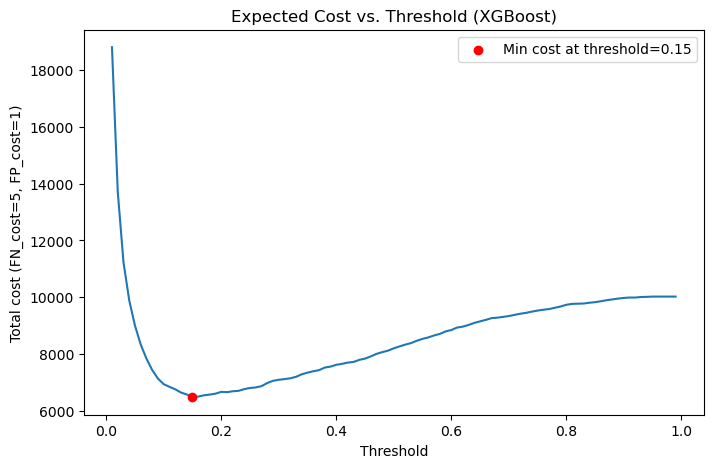

In [77]:
from sklearn.metrics import confusion_matrix

FN_COST = 5  # assumed relative cost of missing an actual defaulter (lost exposure on a bad loan)
FP_COST = 1  # assumed relative cost of unnecessarily flagging a good customer (lost marginal profit)

candidate_thresholds = np.linspace(0.01, 0.99, 99)       #  generates 99 evenly spaced threshold candidates between 0.01 and 0.99 to sweep over
total_costs = []

for t in candidate_thresholds:
    y_pred = (xgb_val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    total_costs.append(FN_COST * fn + FP_COST * fp)

total_costs = np.array(total_costs)
best_idx = np.argmin(total_costs)
best_cost_threshold = candidate_thresholds[best_idx]

# for comparison: cost at the default 0.5 threshold
default_pred = (xgb_val_proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, default_pred).ravel()
cost_at_default = FN_COST * fn + FP_COST * fp

print(f'best threshold: {best_cost_threshold:.3f}')
print(f'total cost at best threshold: {total_costs[best_idx]:.0f}')
print(f'total cost at default 0.5 threshold: {cost_at_default:.0f}')

plt.figure(figsize=(8, 5))
plt.plot(candidate_thresholds, total_costs)
plt.scatter(best_cost_threshold, total_costs[best_idx], color='red', zorder=5,
            label=f'Min cost at threshold={best_cost_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel(f'Total cost (FN_cost={FN_COST}, FP_cost={FP_COST})')
plt.title('Expected Cost vs. Threshold (XGBoost)')
plt.legend()
plt.show()


**Everything we have done so far only includes a single split of train/val set, similary we could have chosen a different split which will provide a different AUC score. In order to make our model more robust, using Cross-Validation is highly recommended. Below we only use Stratified K-Fold on L.R and XGB using 5 splits, we obtained the average AUCs which are very close to their respective values in our above calculations, this is because of Hoeffding's Theorem which shows that std is inversely proportional to sample size**

In [78]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(logreg_pipeline, X, y, cv=cv, scoring='roc_auc')
xgb_cv_scores = cross_val_score(xgb_pipeline, X, y, cv=cv, scoring='roc_auc')

print('lr_fold AUCs:', lr_cv_scores)
print(f'lr_mean AUC: {lr_cv_scores.mean():.4f}')
print(f'lr_std AUC:  {lr_cv_scores.std():.4f}')
print('')
print('xgb_fold AUCs:', xgb_cv_scores)
print(f'xgb_mean AUC: {xgb_cv_scores.mean():.4f}')
print(f'xgb_std AUC:  {xgb_cv_scores.std():.4f}')

lr_fold AUCs: [0.84710358 0.84858582 0.85632853 0.84007736 0.85119869]
lr_mean AUC: 0.8487
lr_std AUC:  0.0053

xgb_fold AUCs: [0.85155825 0.85442145 0.86080291 0.84796925 0.85937588]
xgb_mean AUC: 0.8548
xgb_std AUC:  0.0048


**Lastly, I included hyperparamter tuning for xgb to further improve model's predictive power. Obtained AUC ~ 0.865 and also included the parameters that led to the value.** 

In [79]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_distributions = {
    'model__n_estimators': randint(100, 500),      # number of trees
    'model__max_depth': randint(3, 8),             # depth of trees
    'model__learning_rate': uniform(0.01, 0.29),   # equally likely to be picked in [0.01, 0.30]
    'model__subsample': uniform(0.6, 0.4),          # only uses a fraction in [0.6, 1.0] of training rows for each individual tree, resampled every round, which means each tree sees a different subsample set of training rows. This reduces overfitting 
    'model__colsample_bytree': uniform(0.6, 0.4),   # only uses a fraction in [0.6, 1.0] of training columns for each individual tree, resampled every round, which means each tree sees a different subsample set of columns --> reduces overfitting 
    'model__min_child_weight': randint(1, 8),      # each leaf must satisfy # pseudo residuals >= min_child_weight to reduce overfitting to noise
}

search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1        # Since there are 50 different param_distributions and and 5 folds for each, we have total 250 total fit. This tells sklearn to use all the available processing power to run them simultaneously, which shortens run time
)

search.fit(X, y)

print('best params:', search.best_params_)
print('best CV AUC:', search.best_score_)


best params: {'model__colsample_bytree': 0.8783137597380328, 'model__learning_rate': 0.0762795063212169, 'model__max_depth': 4, 'model__min_child_weight': 1, 'model__n_estimators': 159, 'model__subsample': 0.7043316699321636}
best CV AUC: 0.8649381580707631


# Summary Part 1


**Goal**: predict probability of serious delinquency within 2 years using the "Give Me Some Credit" dataset (150,000 borrowers, ~6.7% default rate).

**Methodology**
1. Explored missingness (`MonthlyIncome`: 19.8%, `NumberOfDependents`: 2.6%) and confirmed severe class imbalance, ruling out accuracy as an evaluation metric.
2. Split off a stratified validation set from `cs-training.csv` (Kaggle's `cs-test.csv` has no usable labels — confirmed early on).
3. Realised that:
   - `RevolvingUtilizationOfUnsecuredLines` had extreme outliers (max 50,708) --> Cap at the train-derived 99th percentile.
   - `DebtRatio`'s extreme values (max 329,664) were shown to correlate almost perfectly (92.6%) with missing `MonthlyIncome` — strong evidence the raw debt amount was stored in place of a ratio when income was unreported. Fixing this added a `MonthlyIncome_was_missing` flag and recovered a per-row ratio estimate.
4. Built a `SimpleImputer` (median) → `StandardScaler` → `LogisticRegression` --> obtained **AUC = 0.812**.
5. Built an `XGBClassifier` baseline (median-imputed only, no scaling needed): **AUC = 0.859** — slightly over logistic regression, consistent with XGBoost's ability to capture non-linear feature interactions.
5. Investigated *why* there is a gap, rather than accepting it:
   - The three late-payment count columns showed suspiciously high pairwise correlation (0.98–0.99), traced to 214 rows sharing an identical sentinel value (98 or 96) across all three columns — a data-encoding artifact, not real payment history. Flagging and nulling these rows fixed both a counterintuitive negative coefficient (multicollinearity-driven sign flip) and pushed logistic regression to **AUC = 0.854** — nearly matching XGBoost's 0.859 through data cleaning alone, no hyperparameter tuning.
6. Wrapped the full cleaning → impute → scale → model sequence into a single `sklearn.Pipeline` with a custom `CreditDataCleaner` transformer, enforcing the fit-on-train-only discipline structurally rather than manually.
7. Explored threshold selection beyond the default 0.5: F1-maximizing threshold (found by direct search over `precision_recall_curve`, since precision/recall are step functions of a finite sample — not differentiable), and a cost-based threshold that explicitly weights missing a defaulter more heavily than a false alarm (assumed 5:1 ratio, since the dataset lacks loan amount/LGD data needed for a real cost figure).
8. Used Cross-Validation to find average AUCs for XGB and L.R
9. Did Hyperparamter tuning on xgb to improve AUC score

**Key results**

| Model | AUC |
|---|---|
| Logistic regression (DebtRatio/income and capped utilization fix) | 0.812 |
| Logistic regression (+ late-payment sentinel fix) | **0.854** |
| Logistic regression (all fixes + Cross-Validation) | **0.849** |
| XGBoost (after same fixes) | **0.859** |
| XGBoost (+ Cross-Validation) | **0.859** |
| XGBoost (+ Hyperparamter tuning) | **0.865** |

**Limitations / honest scope**: this project produces a PD (probability of default) model only. A real credit decision requires $EL = PD \times LGD \times EAD$, and this dataset has no loan amount or loss-given-default data — so threshold/cost analysis here is illustrative of the *methodology*, not a deployable dollar-optimal cutoff.


# Part 2: Credit Risk Segmentation (Logistic Regression)

**We first look at the distribution of `val_proba_v3` before choosing a bucketing method: Default rate here is ~6.7%, so we expect `val_proba_v3` to be heavily right-skewed --> A suitable option for bucketing probabilties is `pd.qcut` (equal-count quintiles) which determines the percentiles and bucket them into intervals as shown below.**

In [122]:
print(y_val.value_counts(normalize=True))

print()
percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99, 100]
print('Percentiles of val_proba_v3:')
print(pd.Series(np.percentile(val_proba_v3, percentiles), index=[f'{p}%' for p in percentiles]))

print()
print('Where would equal-count quintile cuts (pd.qcut, 5 bins) land?')
print(pd.qcut(val_proba_v3, 5).value_counts().sort_index())      # splits into 5 intervals, so it only considers 0/20/40/60/80/100 percentiles --> [0, 20th], (20th, 40th],..., (80th, 100th

SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64

Percentiles of val_proba_v3:
0%      1.139879e-16
10%     1.214576e-02
20%     1.533153e-02
30%     1.860681e-02
40%     2.231638e-02
50%     2.737686e-02
60%     3.616215e-02
70%     5.358638e-02
80%     8.763266e-02
90%     1.446148e-01
95%     2.356175e-01
99%     6.720368e-01
100%    9.994316e-01
dtype: float64

Where would equal-count quintile cuts (pd.qcut, 5 bins) land?
(-0.000999999999999886, 0.0153]    6000
(0.0153, 0.0223]                   6000
(0.0223, 0.0362]                   6000
(0.0362, 0.0876]                   6000
(0.0876, 0.999]                    6000
Name: count, dtype: int64


**We then bucket into risk tiers A–E (quintiles) using the `pd.qcut` above, labeled A (lowest predicted risk) → E (highest).**

In [127]:
results = pd.DataFrame({
    'val_proba': val_proba_v3,
    'y_val': y_val.values
}, index=X_val.index)

results['risk_tier'] = pd.qcut(results['val_proba'], 5, labels=['A', 'B', 'C', 'D', 'E'])

results.groupby('risk_tier', observed=True)['val_proba'].agg(['min', 'max', 'count'])

,min,max,count
risk_tier,,,
A,1.139879e-16,0.015331,6000
B,1.533156e-02,0.022316,6000
C,2.231642e-02,0.036159,6000
D,3.616648e-02,0.087618,6000
E,8.768947e-02,0.999432,6000


**For `results` to make sense, we have to validate the tiers — actual default rate per tier — to test whether `y_val` (actual outcome) agrees --> i.e. whether people we scored as tier E really did default far more often than tier A. If this isn't monotonic, or the gap between adjacent tiers is tiny, that's a signal to revisit bucketing method rather than trust the labels as-is. We also compare each tier's actual default rate against its *predicted* mean probability — a well-calibrated model should have these roughly track each other, not just be correctly ordered.**

           n_borrowers  n_defaults  actual_default_rate  predicted_mean_proba
risk_tier                                                                    
A                 6000          33             0.005500              0.011876
B                 6000          70             0.011667              0.018684
C                 6000         139             0.023167              0.027932
D                 6000         364             0.060667              0.056348
E                 6000        1399             0.233167              0.219719

Monotonic A->E increase in actual default rate: True


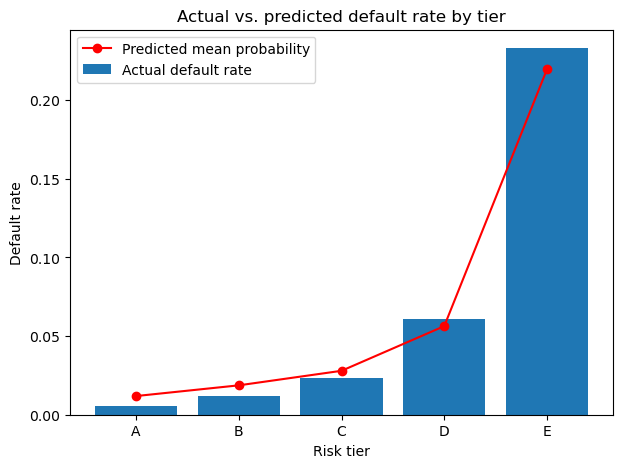

In [128]:
tier_summary = results.groupby('risk_tier', observed=True).agg(
    n_borrowers=('y_val', 'size'),
    n_defaults=('y_val', 'sum'),
    actual_default_rate=('y_val', 'mean'),
    predicted_mean_proba=('val_proba', 'mean')   
)

print(tier_summary)
print()
print('Monotonic A->E increase in actual default rate:', tier_summary['actual_default_rate'].is_monotonic_increasing)

plt.figure(figsize=(7, 5))
plt.bar(tier_summary.index.astype(str), tier_summary['actual_default_rate'], label='Actual default rate')
plt.plot(tier_summary.index.astype(str), tier_summary['predicted_mean_proba'], color='red', marker='o', label='Predicted mean probability')
plt.xlabel('Risk tier')
plt.ylabel('Default rate')
plt.title('Actual vs. predicted default rate by tier')
plt.legend()
plt.show()


**Next, we explain individual borrowers — i.e the reason why they land in specific tiers. To do that, we have to look at each feature's contribution. `X_val_v3_scaled` gives us the exact scaled values the model scored. Multiplying each by its coefficient gives that feature's contribution to this specific borrower's logit, summing all contributions plus the intercept and passing through `sigmoid` should reproduce `val_proba_v3` exactly (sanity check below) before we trust the per-feature breakdown.**

In [130]:
coefficients = pd.Series(model_v3.coef_[0], index=X_val.columns).sort_values(key=abs, ascending=False)
contributions = X_val_v3_scaled * coefficients   # elementwise: contribution_i = scaled_feature_i * coef_i
logit = contributions.sum(axis=1) + model_v3.intercept_[0]
reconstructed_proba = 1 / (1 + np.exp(-logit))

# sanity check: this should match val_proba (up to floating point noise)
max_diff = (reconstructed_proba.values - val_proba_v3).__abs__().max()
print('Max difference between reconstructed and actual val_proba:', max_diff)

Max difference between reconstructed and actual val_proba: 3.885780586188048e-16


**We compare 5 most important features (3 late payments, monthly income and balance owed in unsecured credit lines) between A, C and E.**

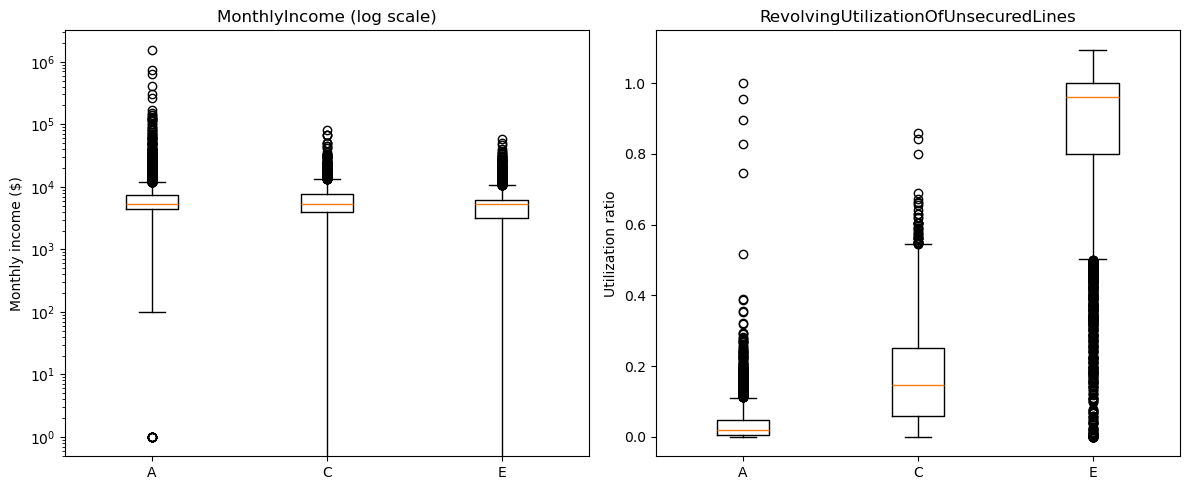

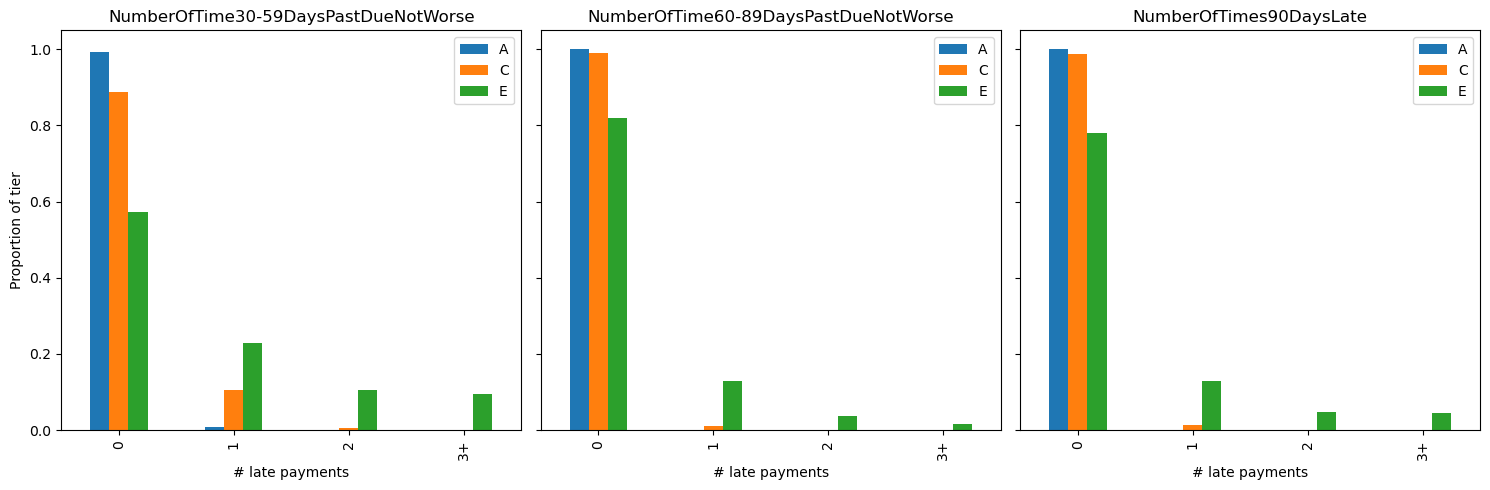

In [134]:
tier_A_raw = X_val_v3_imputed[results['risk_tier'] == 'A']
tier_C_raw = X_val_v3_imputed[results['risk_tier'] == 'C']
tier_E_raw = X_val_v3_imputed[results['risk_tier'] == 'E']

# --- MonthlyIncome and RevolvingUtilizationOfUnsecuredLines: box plots (A vs C vs E) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(
    [tier_A_raw['MonthlyIncome'], tier_C_raw['MonthlyIncome'], tier_E_raw['MonthlyIncome']],
    tick_labels=['A', 'C', 'E']
)
axes[0].set_yscale('log')
axes[0].set_title('MonthlyIncome (log scale)')
axes[0].set_ylabel('Monthly income ($)')
axes[1].boxplot(
    [tier_A_raw['RevolvingUtilizationOfUnsecuredLines'], tier_C_raw['RevolvingUtilizationOfUnsecuredLines'], tier_E_raw['RevolvingUtilizationOfUnsecuredLines']],
    tick_labels=['A', 'C', 'E']
)
axes[1].set_title('RevolvingUtilizationOfUnsecuredLines')
axes[1].set_ylabel('Utilization ratio')

plt.tight_layout()
plt.show()

# --- Late payment columns: proportion per count bucket (0, 1, 2, 3+), A vs C vs E ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, col in zip(axes, late_payment_cols):       # late_payment_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']
    a_counts = tier_A_raw[col].clip(upper=3).value_counts(normalize=True).sort_index()
    c_counts = tier_C_raw[col].clip(upper=3).value_counts(normalize=True).sort_index()            
    e_counts = tier_E_raw[col].clip(upper=3).value_counts(normalize=True).sort_index()
    combined = pd.DataFrame({'A': a_counts, 'C': c_counts, 'E': e_counts}).fillna(0)
    combined.index = [f'{int(i)}+' if i == 3 else str(int(i)) for i in combined.index]

    combined.plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('# late payments')
    ax.set_ylabel('Proportion of tier')

plt.tight_layout()
plt.show()


**- `RevolvingUtilizationOfUnsecuredLines` shows us the upward trend from A to E which supports our bucketing method ---- i.e, higher amount owed --> higher risk.**

**- The 3 late-payment columns also show us that borrowers with past overdue payments are riskier**    

**- `MonthlyIncome` for borrowers in A, C and E are similar except A has lower spread but with more higher outlier values --> meaning that A is earning more, on average, than C and E; C and E earns approximately the same.**

## Scorecard

- We will use a scoring method suggested by Siddiqi's Intelligent Credit Scoring book: **Score = Offset + Factor * log(odds)**. 
    - Terminologies: 
        1) **odds** = P(non-default)/P(default)  
        2) **Factor** is the scaling needed for score to increase by a certain fixed point (**PDO**: points to double the good odds) when odds double - i.e **Score + PDO = Offset + Factor * log(2 * odds)**. 
        3) **Offset** is just a translating factor that can be found if we have a reference point.

- **Why this formula?**: 
    - Logistic Regression's logit function is a linear function of the features --> **Score** formula is able to tell us the contribution scores of each feature

In [135]:
BASE_SCORE = 600
BASE_ODDS = 50    
PDO = 20          # These numbers are just for illustrative pruposes and does not represent real data

FACTOR = PDO / np.log(2)     # From definition of Factor
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)

print(f'Factor: {FACTOR:.4f}, Offset: {OFFSET:.4f}')

results['score'] = OFFSET - FACTOR * logit    # logit = - log(odds)

print()
print(results['score'].describe())

print()
print('Score range per existing risk tier:')
print(results.groupby('risk_tier', observed=True)['score'].agg(['min', 'max', 'mean']))

Factor: 28.8539, Offset: 487.1229

count    30000.000000
mean       580.909649
std         34.474202
min        271.522867
25%        562.602341
50%        590.139916
75%        604.303782
max       1546.362250
Name: score, dtype: float64

Score range per existing risk tier:
                  min          max        mean
risk_tier                                     
A          607.224328  1546.362250  615.743529
B          596.186821   607.224117  601.586019
C          581.850029   596.186675  589.820592
D          554.729485   581.844055  569.410971
E          271.522867   554.703866  527.987133


**We now bin/group each feature into a maximum of 5 intervals calculated from 0/20/40/60/80/100 percentiles and calculate the mean scores of each interval --> these mean scores will be used to determine outliers as we will see.** 

In [ ]:
N_BINS = 5          # It's just a choice

base_points = OFFSET - FACTOR * model_v3.intercept_[0]

binned_features = {}
bin_points_by_feature = {}
scorecard_rows = []

for col in X_val.columns:
    binned = pd.qcut(X_val_v3_imputed[col], q=N_BINS, duplicates='drop')       # split each column into 0/20/40/60/80/100 percentiles (i.e, 5 intervals), but duplicates='drop' merges duplicate percentiles 
                                                                               # --> reducing number of intervals
                                                                               
    bin_points = (-FACTOR * contributions[col]).groupby(binned, observed=True).mean()      # for each column, it calculates the mean score of each feature for every interval 

    binned_features[col] = binned
    bin_points_by_feature[col] = bin_points

    bin_counts = binned.value_counts()
    for interval, points in bin_points.items():
        scorecard_rows.append({
            'feature': col,
            'bin': str(interval),
            'points': round(points, 1),
            'n_borrowers': int(bin_counts[interval])
        })

scorecard_df = pd.DataFrame(scorecard_rows)      # Age and MonthlyIncome especially, showing n_borrowers having values different from 6000, that's because the right-end value of each interval contains duplicate rows 
print(scorecard_df.to_string(index=False))

# --- Validate: summing base + binned points should approximately reconstruct the continuous score ---
reconstructed_points = pd.DataFrame({
    col: binned_features[col].map(bin_points_by_feature[col])       # binned_features[col] shows the interval that the rows fall into, .map(bin_points_by_feature[col]) substitutes the intervals for the average calculated that corresponds to that interval
    for col in X_val.columns
}, index=X_val.index)

reconstructed_score = base_points + reconstructed_points.sum(axis=1)      
error = (reconstructed_score - results['score']).abs()

print()
print('Reconstruction error (binned score vs. exact continuous score):')
print(error.describe())


                             feature                 bin  points  n_borrowers
RevolvingUtilizationOfUnsecuredLines      (-0.001, 0.02]    18.8         6000
RevolvingUtilizationOfUnsecuredLines      (0.02, 0.0854]    16.3         6000
RevolvingUtilizationOfUnsecuredLines     (0.0854, 0.275]     9.2         6000
RevolvingUtilizationOfUnsecuredLines       (0.275, 0.71]    -8.6         6000
RevolvingUtilizationOfUnsecuredLines       (0.71, 1.094]   -36.9         6000
                                 age      (20.999, 39.0]    -9.9         6368
                                 age        (39.0, 48.0]    -4.0         6150
                                 age        (48.0, 56.0]     0.0         5772
                                 age        (56.0, 65.0]     4.3         5961
                                 age       (65.0, 109.0]    10.8         5749
NumberOfTime30-59DaysPastDueNotWorse       (-0.001, 9.0]    -0.0        30000
                           DebtRatio    (-0.001, 0.0799]    -0.1

**Notice that the mean-error is reasonable which means that, on average, the total binning has accuracy up to +- 10, even when the max is 964 --> this large max error indicates that there are rows with large errors which pulls the mean error up. Studying these large errors will us identify outliers within each tier as we will see. Looking back to the `scorecard_df` above, we can notice that the 3 late-payment columns only has 1 bin each with means close to 0, which I think caused a significant portion of the error --> the reason being they contain too many zeros. Let's actually increase the number of bins for these 3 columns.**

In [137]:
N_BINS = 5
CUSTOM_BIN_EDGES = {
    'NumberOfTime30-59DaysPastDueNotWorse': [-np.inf, 0, 1, 2, np.inf],          # zero-inflated count columns: qcut collapses these to 1 bin (all percentile checkpoints land on the same repeated value),
    'NumberOfTime60-89DaysPastDueNotWorse': [-np.inf, 0, 1, 2, np.inf],          # so we use fixed cutoffs instead of equal-frequency percentiles.
    'NumberOfTimes90DaysLate': [-np.inf, 0, 1, 2, np.inf],                       
}
CUSTOM_BIN_LABELS = ['0', '1', '2', '3+']

base_points = OFFSET - FACTOR * model_v3.intercept_[0]

binned_features = {}
bin_points_by_feature = {}
scorecard_rows = []

for col in X_val.columns:
    if col in CUSTOM_BIN_EDGES:
        binned = pd.cut(X_val_v3_imputed[col], bins=CUSTOM_BIN_EDGES[col], labels=CUSTOM_BIN_LABELS)
    else:
        binned = pd.qcut(X_val_v3_imputed[col], q=N_BINS, duplicates='drop')

    bin_points = (-FACTOR * contributions[col]).groupby(binned, observed=True).mean()

    binned_features[col] = binned
    bin_points_by_feature[col] = bin_points

    bin_counts = binned.value_counts()
    for interval, points in bin_points.items():
        scorecard_rows.append({
            'feature': col,
            'bin': str(interval),
            'points': round(points, 1),
            'n_borrowers': int(bin_counts[interval])
        })

scorecard_df = pd.DataFrame(scorecard_rows)
print(scorecard_df.to_string(index=False))

# --- Validate: summing base + binned points should approximately reconstruct the continuous score ---
reconstructed_points = pd.DataFrame({
    col: binned_features[col].map(bin_points_by_feature[col])
    for col in X_val.columns
}, index=X_val.index)

reconstructed_score = base_points + reconstructed_points.sum(axis=1)
error = (reconstructed_score - results['score']).abs()

print()
print('Reconstruction error (binned score vs. exact continuous score):')
print(error.describe())


                             feature                 bin  points  n_borrowers
RevolvingUtilizationOfUnsecuredLines      (-0.001, 0.02]    18.8         6000
RevolvingUtilizationOfUnsecuredLines      (0.02, 0.0854]    16.3         6000
RevolvingUtilizationOfUnsecuredLines     (0.0854, 0.275]     9.2         6000
RevolvingUtilizationOfUnsecuredLines       (0.275, 0.71]    -8.6         6000
RevolvingUtilizationOfUnsecuredLines       (0.71, 1.094]   -36.9         6000
                                 age      (20.999, 39.0]    -9.9         6368
                                 age        (39.0, 48.0]    -4.0         6150
                                 age        (48.0, 56.0]     0.0         5772
                                 age        (56.0, 65.0]     4.3         5961
                                 age       (65.0, 109.0]    10.8         5749
NumberOfTime30-59DaysPastDueNotWorse                   0     2.9        25279
NumberOfTime30-59DaysPastDueNotWorse                   1    -9.0

**We can notice that mean error has gone down significantly but the max is still large. Let's check what caused the error.**

In [138]:
worst_idx = error.idxmax()

print('Borrower:', worst_idx, '| reconstruction error:', error.loc[worst_idx])
print()
print('Raw (cleaned + imputed) feature values:')
print(X_val_v3_imputed.loc[worst_idx])
print()

comparison = pd.DataFrame({
    'true_points': -FACTOR * contributions.loc[worst_idx],
    'binned_points': reconstructed_points.loc[worst_idx]
})
comparison['gap'] = comparison['binned_points'] - comparison['true_points']
print('True (continuous) vs. binned points per feature, sorted by gap size:')
print(comparison.sort_values('gap', key=abs, ascending=False))


Borrower: 111366 | reconstruction error: 958.3031960859448

Raw (cleaned + imputed) feature values:
RevolvingUtilizationOfUnsecuredLines    1.638562e-01
age                                     4.400000e+01
NumberOfTime30-59DaysPastDueNotWorse    0.000000e+00
DebtRatio                               4.012561e-03
MonthlyIncome                           1.560100e+06
NumberOfOpenCreditLinesAndLoans         1.200000e+01
NumberOfTimes90DaysLate                 0.000000e+00
NumberRealEstateLoansOrLines            4.000000e+00
NumberOfTime60-89DaysPastDueNotWorse    0.000000e+00
NumberOfDependents                      2.000000e+00
Name: 111366, dtype: float64

True (continuous) vs. binned points per feature, sorted by gap size:
                                      true_points  binned_points           gap
MonthlyIncome                          965.867671       4.542902 -9.613248e+02
NumberOfDependents                      -1.326438       0.273484  1.599921e+00
NumberOfOpenCreditLinesAndLoans   

**The large error originates from `MonthlyIncome`'s outlier which tells us that `MonthlyIncome` also contributes a fair amount to the error. However, `MonthlyIncome` has already been binned into 5 intervals, increasing the number of bins would not help much because the outliers will still affect the mean score of the new bin they are in. If we want to eliminate these large errors, we have to separate these outliers into their own specific bins but doing this would defeat the purpose of binning in the first place. To resolve this, we can actually flag borrowers that exceed a certain fixed error threshold and manually review them.**

In [139]:
NEEDS_REVIEW_THRESHOLD = PDO   # more than one full "doubling of odds" worth of table error

results['reconstruction_error'] = error
results['needs_individual_review'] = results['reconstruction_error'] > NEEDS_REVIEW_THRESHOLD

n_flagged = results['needs_individual_review'].sum()
print(f'Borrowers flagged for individual review (error > {NEEDS_REVIEW_THRESHOLD} points): '
      f'{n_flagged} out of {len(results)} ({n_flagged / len(results):.2%})')

print()
print('Flagged borrowers by risk tier:')
print(results[results['needs_individual_review']]['risk_tier'].value_counts().sort_index())

Borrowers flagged for individual review (error > 20 points): 349 out of 30000 (1.16%)

Flagged borrowers by risk tier:
risk_tier
A     62
B     13
C     16
D     30
E    228
Name: count, dtype: int64


**A and E contained the most flagging which is consistent with our explanation that `MonthlyIncome`'s outliers contributed to large errors in A and the 3 late-payment columns' outliers contributed to large errors in E.**

# Summary Part 2

**Goal**: bucket borrowers into risk tiers (A–E) using the *already-trained* logistic regression pipeline, then validate, explain, and translate those tiers into something a lender could actually act on.

**Methodology**

1. Examined `val_proba`'s distribution before bucketing, heavily right-skewed (median ≈2.7%, 99th percentile ≈6.7%), then split into 5 equal-count percentile tiers via `pd.qcut`.
2. Validated the tiers against true outcomes: actual default rate increases monotonically A→E, and each tier's actual rate tracks its predicted mean probability closely, confirming the tiers reflect real risk separation.
3. Explained tier placement using decomposition of the logit into additive feature contributions for each borrower, then used high-beta features to directly compare between tiers A, C and E --> showed consistent trends. 
4. Built a points-based scorecard:
   - For Logistic Regression, `Score = Offset − Factor × logit` is used which preserves additivity across features (probability itself doesn't decompose additively).
   - Used illustrative values (base score 600 at 50:1 good:bad odds, 20 points to double the odds) --> does not reflect real data.
   - Built the points table by binning each feature and averaging bin-level contributions, then caught and fixed a real defect: the zero-inflated late-payment columns (~90% zero) caused `qcut`'s percentiles to collapse onto one bin --> fixed with fixed cutoffs (0/1/2/3+) instead of percentiles.
   - Found a second defect: rare extreme outliers (e.g. a borrower earning $1.56M/month) get diluted toward their bin's average, a tradeoff of any binned scorecard, not something more bins can fix.
   - Added a review flag (reconstruction error > one PDO cycle) to manually isolate borrowers the table misrepresents instead of trusting blindly — 1.16% of borrowers flagged, concentrated in tier E.

**Limitations**: 
    - Part 2 of this project scores and tiers borrowers only, the decision-making process is not illustrated here because it differs between lenders.

**Remark**:
    - This project was done by modelling the data first before binning each feature to calculate the scores. According to Siddiqi's Intelligent credit scoring book, binning is done before modelling and the actual credit scoring is different. I would highly recommend consulting the book if any doubts arise.


# Reference:

- Naeem Siddiqi, *Intelligent Credit Scoring: Building and Implementing Better Credit Risk Scorecards*, 2nd ed. (Wiley, 2017)